# 지하철 승하차 인원 분석 프로젝트
- 2015년 1월부터 2025년 9월까지 수집된 데이터
- 지하철 이용 승객 수를 확인해보면 혼잡도가 높은 지역을 확인할 수 있음
- 지하철 호선별 역별 승하차 인원 정보데이터를 분석

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#차트에서 한글파일 깨질때

import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [6]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv',encoding='cp949')
data.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202509,1호선,동대문,535,13,12099,1984,9918,7427,17438,...,10017,978,3111,5,349,0,0,0,0,20251003
1,202509,1호선,동묘앞,202,4,2934,890,4096,5669,9623,...,4829,171,2095,0,289,0,0,0,0,20251003
2,202509,1호선,서울역,753,35,11376,10334,32529,62503,105429,...,29456,4658,7703,13,173,0,0,0,0,20251003
3,202509,1호선,시청,78,5,1832,6166,4039,35164,7843,...,3512,651,991,1,29,0,0,0,0,20251003
4,202509,1호선,신설동,454,10,9125,2340,10625,9290,24255,...,9200,478,2787,0,0,0,0,0,0,20251003


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76764 entries, 0 to 76763
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   사용월           76764 non-null  int64 
 1   호선명           76764 non-null  object
 2   지하철역          76764 non-null  object
 3   04시-05시 승차인원  76764 non-null  int64 
 4   04시-05시 하차인원  76764 non-null  int64 
 5   05시-06시 승차인원  76764 non-null  int64 
 6   05시-06시 하차인원  76764 non-null  int64 
 7   06시-07시 승차인원  76764 non-null  int64 
 8   06시-07시 하차인원  76764 non-null  int64 
 9   07시-08시 승차인원  76764 non-null  int64 
 10  07시-08시 하차인원  76764 non-null  int64 
 11  08시-09시 승차인원  76764 non-null  int64 
 12  08시-09시 하차인원  76764 non-null  int64 
 13  09시-10시 승차인원  76764 non-null  int64 
 14  09시-10시 하차인원  76764 non-null  int64 
 15  10시-11시 승차인원  76764 non-null  int64 
 16  10시-11시 하차인원  76764 non-null  int64 
 17  11시-12시 승차인원  76764 non-null  int64 
 18  11시-12시 하차인원  76764 non-null  int64 
 19  12시-

In [8]:
data.describe()

,사용월,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,07시-08시 하차인원,08시-09시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
count,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,...,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,76764.000000,7.676400e+04
mean,202006.157066,208.628459,3.051000,5160.443841,1305.766688,10619.547574,7022.983560,27079.069551,16075.246496,30793.867946,...,8935.642176,614.312178,2604.312894,3.305964,82.743969,0.227802,0.982687,0.012975,0.068665,2.020145e+07
std,308.878561,688.536866,8.008859,5891.452800,1448.463112,10386.556497,7565.764798,27649.067477,21049.612066,32451.231706,...,10156.001342,1444.217270,3390.002052,32.859358,313.314527,15.099773,11.310280,0.602042,2.981226,3.083478e+04
min,201501.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.015121e+07
25%,201711.000000,4.000000,0.000000,1443.000000,398.000000,3388.000000,2304.750000,7891.750000,4546.000000,9699.000000,...,2710.000000,17.000000,526.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.017120e+07
50%,202007.000000,23.000000,0.000000,3394.000000,896.000000,7654.000000,4749.500000,19131.000000,9162.000000,21643.500000,...,6056.000000,162.000000,1571.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.020080e+07
75%,202303.000000,119.000000,3.000000,6649.250000,1650.000000,14346.000000,8996.000000,36434.250000,18790.500000,41001.500000,...,11560.000000,602.000000,3449.250000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,2.023040e+07
max,202509.000000,14749.000000,218.000000,59655.000000,15843.000000,99232.000000,87300.000000,294593.000000,238513.000000,386398.000000,...,134948.000000,33676.000000,46252.000000,2805.000000,6651.000000,3082.000000,883.000000,94.000000,312.000000,2.025100e+07


In [9]:
data.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202509,1호선,동대문,535,13,12099,1984,9918,7427,17438,...,10017,978,3111,5,349,0,0,0,0,20251003
1,202509,1호선,동묘앞,202,4,2934,890,4096,5669,9623,...,4829,171,2095,0,289,0,0,0,0,20251003
2,202509,1호선,서울역,753,35,11376,10334,32529,62503,105429,...,29456,4658,7703,13,173,0,0,0,0,20251003
3,202509,1호선,시청,78,5,1832,6166,4039,35164,7843,...,3512,651,991,1,29,0,0,0,0,20251003
4,202509,1호선,신설동,454,10,9125,2340,10625,9290,24255,...,9200,478,2787,0,0,0,0,0,0,20251003


In [13]:
sorted(list(set(data['호선명'])))

['1호선',
 '2호선',
 '3호선',
 '4호선',
 '5호선',
 '6호선',
 '7호선',
 '8호선',
 '9호선',
 '9호선2~3단계',
 '9호선2단계',
 '경강선',
 '경부선',
 '경원선',
 '경의선',
 '경인선',
 '경춘선',
 '공항철도 1호선',
 '과천선',
 '분당선',
 '서해선',
 '수인선',
 '신림선',
 '안산선',
 '우이신설선',
 '일산선',
 '장항선',
 '중앙선']

In [14]:
sorted(list(set(data['지하철역'])))

['4.19민주묘지',
 '가능',
 '가락시장',
 '가산디지털단지',
 '가양',
 '가오리',
 '가좌',
 '가천대',
 '가평',
 '간석',
 '갈매',
 '강남',
 '강남구청',
 '강동',
 '강동구청',
 '강매',
 '강변',
 '강변(동서울터미널)',
 '강일',
 '강촌',
 '개롱',
 '개봉',
 '개포동',
 '개화',
 '개화산',
 '거여',
 '건대입구',
 '검암',
 '경기광주',
 '경마공원',
 '경복궁',
 '경복궁(정부서울청사)',
 '경찰병원',
 '계양',
 '고덕',
 '고려대',
 '고려대(종암)',
 '고색',
 '고속터미널',
 '고잔',
 '곡산',
 '곤지암',
 '공덕',
 '공릉',
 '공릉(서울과학기술대)',
 '공항시장',
 '공항화물청사',
 '과천',
 '관악',
 '관악산(서울대)',
 '광나루',
 '광나루(장신대)',
 '광명',
 '광명사거리',
 '광운대',
 '광화문',
 '광화문(세종문화회관)',
 '광흥창',
 '광흥창(서강)',
 '교대',
 '교대(법원.검찰청)',
 '구로',
 '구로디지털단지',
 '구룡',
 '구리',
 '구반포',
 '구산',
 '구성',
 '구의',
 '구의(광진구청)',
 '구일',
 '구파발',
 '국수',
 '국회의사당',
 '군자',
 '군자(능동)',
 '군포',
 '굴봉산',
 '굴포천',
 '굽은다리',
 '굽은다리(강동구민회관앞)',
 '금곡',
 '금릉',
 '금정',
 '금천구청',
 '금촌',
 '금호',
 '기흥',
 '길동',
 '길음',
 '김유정',
 '김포공항',
 '까치산',
 '까치울',
 '낙성대',
 '낙성대(강감찬)',
 '남구로',
 '남동인더스파크',
 '남부터미널',
 '남부터미널(예술의전당)',
 '남성',
 '남영',
 '남위례',
 '남춘천',
 '남태령',
 '남한산성입구',
 '남한산성입구(성남법원.검찰청)',
 '내방',
 '노들',
 '노량진',
 '노원',
 '녹번',
 '녹사평(용산구청)',

In [15]:
len(list(set(data['지하철역'])))

600

In [16]:
metro_recen = data[data['사용월']==202509]

In [18]:
data = metro_recen.drop(columns=['작업일자'])
data.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 승차인원,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원
0,202509,1호선,동대문,535,13,12099,1984,9918,7427,17438,...,5832,10017,978,3111,5,349,0,0,0,0
1,202509,1호선,동묘앞,202,4,2934,890,4096,5669,9623,...,1285,4829,171,2095,0,289,0,0,0,0
2,202509,1호선,서울역,753,35,11376,10334,32529,62503,105429,...,33814,29456,4658,7703,13,173,0,0,0,0
3,202509,1호선,시청,78,5,1832,6166,4039,35164,7843,...,10419,3512,651,991,1,29,0,0,0,0
4,202509,1호선,신설동,454,10,9125,2340,10625,9290,24255,...,3794,9200,478,2787,0,0,0,0,0,0


In [24]:
# 호선별 이용객수 시각화
data_line = data.groupby('호선명').mean(numeric_only=True).reset_index()

In [25]:
#drop 선택한 행,열을 삭제한 새로운 객체 생성
data_line = data_line.drop(columns='사용월').set_index('호선명')
data_line = data_line.mean(axis=1).sort_values(ascending=False)

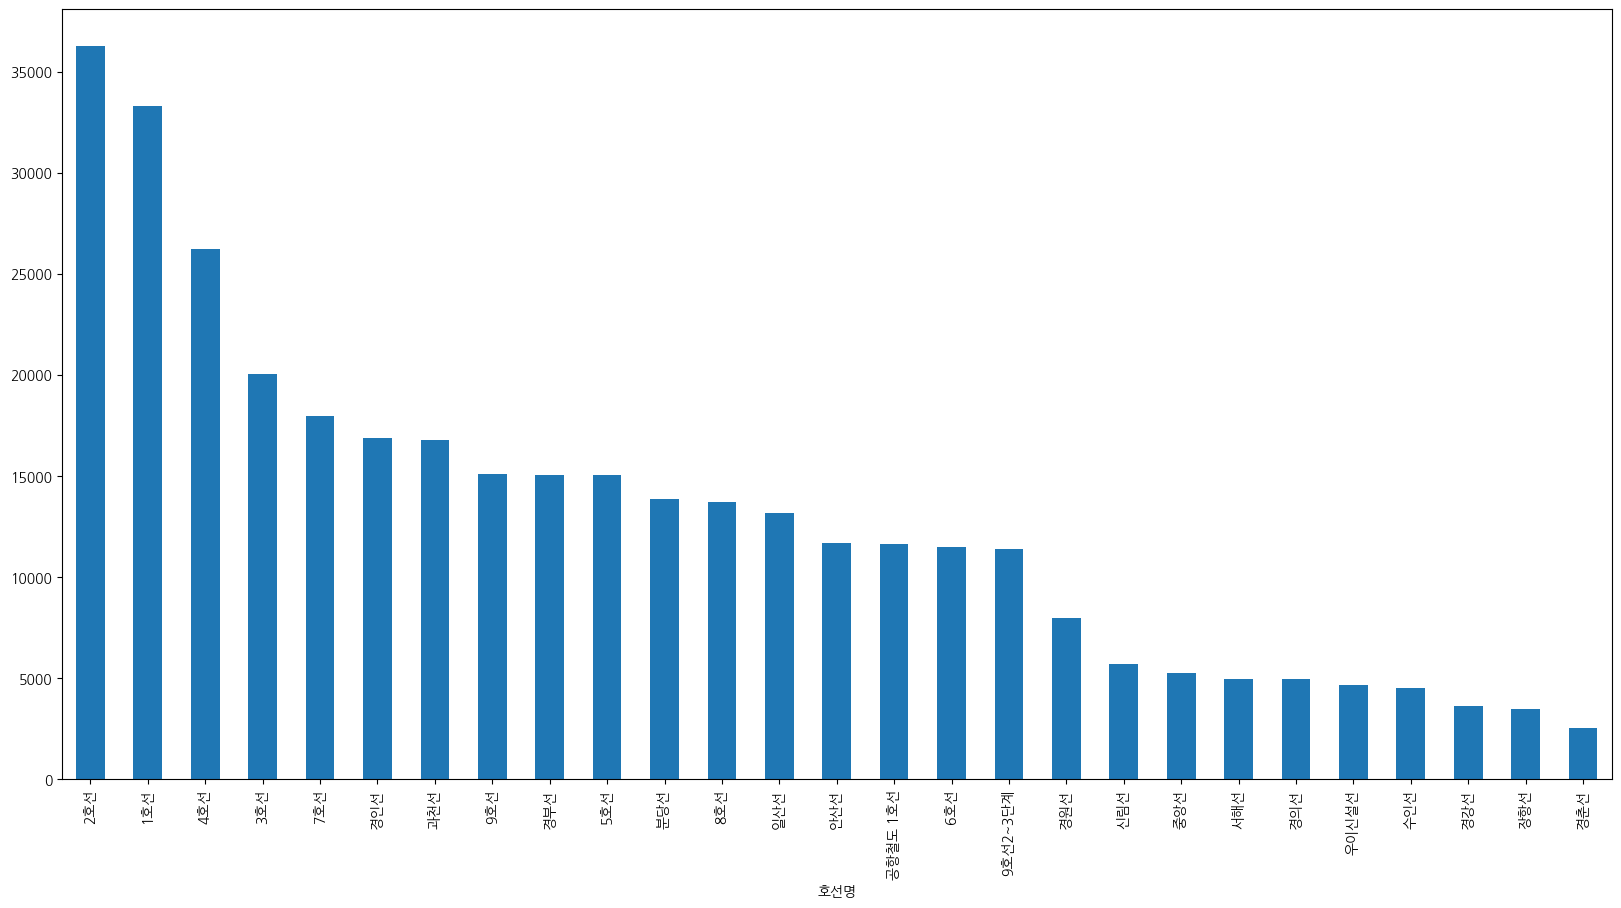

In [26]:
plt.figure(figsize=(20,10))
data_line.plot(kind=('bar'))
plt.show()

In [28]:
# 특정 호선에서 역별 평균 승하차 인원 데이터 추출
line = '2호선'
data_st = data.groupby(['호선명','지하철역']).mean().reset_index()
data_line2 = data_st[data_st['호선명']==line]
data_line2

,호선명,지하철역,사용월,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 승차인원,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원
10,2호선,강남,202509.0,129.0,9.0,8007.0,12131.0,17685.0,57947.0,43173.0,...,69262.0,22181.0,11674.0,6420.0,6.0,26.0,0.0,0.0,0.0,0.0
11,2호선,강변(동서울터미널),202509.0,45.0,1.0,9161.0,1945.0,23656.0,22079.0,70680.0,...,5788.0,16531.0,876.0,4517.0,0.0,101.0,0.0,0.0,0.0,0.0
12,2호선,건대입구,202509.0,333.0,18.0,14655.0,1690.0,23621.0,15867.0,59485.0,...,40833.0,33492.0,7012.0,11703.0,12.0,982.0,0.0,0.0,0.0,0.0
13,2호선,교대(법원.검찰청),202509.0,20.0,0.0,2506.0,6590.0,11471.0,29177.0,27316.0,...,15151.0,11652.0,3058.0,3634.0,1.0,19.0,0.0,0.0,0.0,0.0
14,2호선,구로디지털단지,202509.0,540.0,15.0,39944.0,4728.0,56218.0,21123.0,148433.0,...,18262.0,47932.0,3549.0,14315.0,4.0,343.0,0.0,0.0,0.0,0.0
15,2호선,구의(광진구청),202509.0,75.0,2.0,14448.0,1374.0,31140.0,12759.0,84635.0,...,8925.0,24659.0,1501.0,7961.0,3.0,117.0,0.0,0.0,0.0,0.0
16,2호선,낙성대(강감찬),202509.0,50.0,4.0,12733.0,2651.0,29343.0,9995.0,92037.0,...,8886.0,33481.0,1706.0,9690.0,5.0,190.0,0.0,0.0,0.0,0.0
17,2호선,당산,202509.0,67.0,11.0,8637.0,4195.0,20643.0,16811.0,50924.0,...,8895.0,19066.0,1525.0,5579.0,7.0,144.0,0.0,0.0,0.0,0.0
18,2호선,대림(구로구청),202509.0,865.0,12.0,35203.0,3301.0,31455.0,11057.0,72686.0,...,5176.0,22661.0,889.0,5469.0,3.0,284.0,0.0,0.0,0.0,0.0
19,2호선,도림천,202509.0,2.0,0.0,400.0,330.0,1641.0,893.0,3877.0,...,230.0,971.0,73.0,335.0,0.0,6.0,0.0,0.0,0.0,0.0


In [30]:
# 승하차 인원은 홀/짝
# 호선명 ,지하철역,사용월 3개 컬럼을 제외한 갯수의 홀/짝 각각의 수를 구해야한다.
# 승차 인원 컬럼만 추출

data_get_on = pd.DataFrame()
data_get_on['지하철역'] = data_line2['지하철역']

cols =data_line2.columns[3:]
data_get_on = pd.concat([data_get_on,data_line2[cols[::2]]],axis=1)

data_get_on = data_get_on.set_index('지하철역')
data_get_on

,04시-05시 승차인원,05시-06시 승차인원,06시-07시 승차인원,07시-08시 승차인원,08시-09시 승차인원,09시-10시 승차인원,10시-11시 승차인원,11시-12시 승차인원,12시-13시 승차인원,13시-14시 승차인원,...,18시-19시 승차인원,19시-20시 승차인원,20시-21시 승차인원,21시-22시 승차인원,22시-23시 승차인원,23시-24시 승차인원,00시-01시 승차인원,01시-02시 승차인원,02시-03시 승차인원,03시-04시 승차인원
지하철역,,,,,,,,,,,,,,,,,,,,,
강남,129.0,8007.0,17685.0,43173.0,67143.0,57876.0,57534.0,73408.0,90497.0,104727.0,...,343023.0,228327.0,173750.0,184014.0,157834.0,69262.0,11674.0,6.0,0.0,0.0
강변(동서울터미널),45.0,9161.0,23656.0,70680.0,104751.0,76519.0,59973.0,50313.0,46848.0,43210.0,...,57651.0,37898.0,29638.0,24148.0,15799.0,5788.0,876.0,0.0,0.0,0.0
건대입구,333.0,14655.0,23621.0,59485.0,101746.0,67525.0,43677.0,40169.0,47617.0,51490.0,...,93294.0,71459.0,72897.0,77462.0,71502.0,40833.0,7012.0,12.0,0.0,0.0
교대(법원.검찰청),20.0,2506.0,11471.0,27316.0,39007.0,31805.0,28933.0,34420.0,35675.0,45160.0,...,142095.0,64742.0,54329.0,51449.0,38635.0,15151.0,3058.0,1.0,0.0,0.0
구로디지털단지,540.0,39944.0,56218.0,148433.0,194204.0,118577.0,70728.0,63018.0,71553.0,67562.0,...,208982.0,102635.0,63225.0,50913.0,39518.0,18262.0,3549.0,4.0,0.0,0.0
구의(광진구청),75.0,14448.0,31140.0,84635.0,132688.0,79394.0,44254.0,35244.0,37484.0,37842.0,...,55395.0,30849.0,24426.0,23279.0,18564.0,8925.0,1501.0,3.0,0.0,0.0
낙성대(강감찬),50.0,12733.0,29343.0,92037.0,135216.0,85546.0,47307.0,38495.0,42235.0,40713.0,...,56306.0,31844.0,25619.0,22714.0,17198.0,8886.0,1706.0,5.0,0.0,0.0
당산,67.0,8637.0,20643.0,50924.0,63720.0,37826.0,27026.0,24775.0,25054.0,23876.0,...,60999.0,28635.0,23600.0,22235.0,17984.0,8895.0,1525.0,7.0,0.0,0.0
대림(구로구청),865.0,35203.0,31455.0,72686.0,98650.0,64934.0,40302.0,34990.0,37189.0,35457.0,...,51157.0,26134.0,18602.0,13774.0,10472.0,5176.0,889.0,3.0,0.0,0.0


In [38]:
# 승하차 인원은 홀/짝
# 호선명 ,지하철역,사용월 3개 컬럼을 제외한 갯수의 홀/짝 각각의 수를 구해야한다.
# 하차 인원 컬럼만 추출

data_get_off = pd.DataFrame()
data_get_off['지하철역'] = data_line2['지하철역']

cols =data_line2.columns[3:]
data_get_off = pd.concat([data_get_off,data_line2[cols[1::2]]],axis=1)

data_get_off = data_get_off.set_index('지하철역')
data_get_off

,04시-05시 하차인원,05시-06시 하차인원,06시-07시 하차인원,07시-08시 하차인원,08시-09시 하차인원,09시-10시 하차인원,10시-11시 하차인원,11시-12시 하차인원,12시-13시 하차인원,13시-14시 하차인원,...,18시-19시 하차인원,19시-20시 하차인원,20시-21시 하차인원,21시-22시 하차인원,22시-23시 하차인원,23시-24시 하차인원,00시-01시 하차인원,01시-02시 하차인원,02시-03시 하차인원,03시-04시 하차인원
지하철역,,,,,,,,,,,,,,,,,,,,,
강남,9.0,12131.0,57947.0,169200.0,346408.0,346621.0,160638.0,106286.0,100988.0,116229.0,...,185493.0,105980.0,60751.0,50673.0,39923.0,22181.0,6420.0,26.0,0.0,0.0
강변(동서울터미널),1.0,1945.0,22079.0,23422.0,40950.0,34163.0,31549.0,31737.0,35210.0,39886.0,...,94093.0,64227.0,46400.0,37456.0,32195.0,16531.0,4517.0,101.0,0.0,0.0
건대입구,18.0,1690.0,15867.0,26125.0,67234.0,52125.0,50175.0,48748.0,55144.0,60042.0,...,157101.0,108732.0,68911.0,63772.0,56714.0,33492.0,11703.0,982.0,0.0,0.0
교대(법원.검찰청),0.0,6590.0,29177.0,62291.0,170520.0,137271.0,73380.0,62426.0,56875.0,60580.0,...,74205.0,41869.0,27741.0,23981.0,22226.0,11652.0,3634.0,19.0,0.0,0.0
구로디지털단지,15.0,4728.0,21123.0,89180.0,231866.0,147407.0,62536.0,46678.0,52616.0,66308.0,...,168925.0,132598.0,88911.0,87105.0,81743.0,47932.0,14315.0,343.0,0.0,0.0
구의(광진구청),2.0,1374.0,12759.0,19889.0,49966.0,28683.0,26255.0,27675.0,30422.0,33358.0,...,113974.0,80697.0,54218.0,49099.0,44911.0,24659.0,7961.0,117.0,0.0,0.0
낙성대(강감찬),4.0,2651.0,9995.0,21616.0,46375.0,38360.0,30461.0,26168.0,29482.0,31686.0,...,107064.0,88911.0,59343.0,56467.0,55606.0,33481.0,9690.0,190.0,0.0,0.0
당산,11.0,4195.0,16811.0,32122.0,81501.0,34778.0,17225.0,16864.0,20016.0,22845.0,...,81255.0,53833.0,36481.0,34688.0,31734.0,19066.0,5579.0,144.0,0.0,0.0
대림(구로구청),12.0,3301.0,11057.0,24917.0,57367.0,35415.0,33175.0,34533.0,33780.0,33090.0,...,71223.0,53243.0,41615.0,50394.0,46975.0,22661.0,5469.0,284.0,0.0,0.0


In [40]:
# 역 별 평균 승하차 인원을 구한 후, 정수로 변환하여 데이터프레임에 저장
df = pd.DataFrame(index=data_line2['지하철역'])
df['평균 승차 인원 수'] = data_get_on.mean(axis=1).astype(int)
df['평균 하차 인원 수'] = data_get_off.mean(axis=1).astype(int)
df


,평균 승차 인원 수,평균 하차 인원 수
지하철역,,
강남,99708,97846
강변(동서울터미널),35195,32359
건대입구,48115,49542
교대(법원.검찰청),37640,45202
구로디지털단지,70080,69634
구의(광진구청),34278,33624
낙성대(강감찬),35617,34674
당산,23643,27101
대림(구로구청),30397,31220


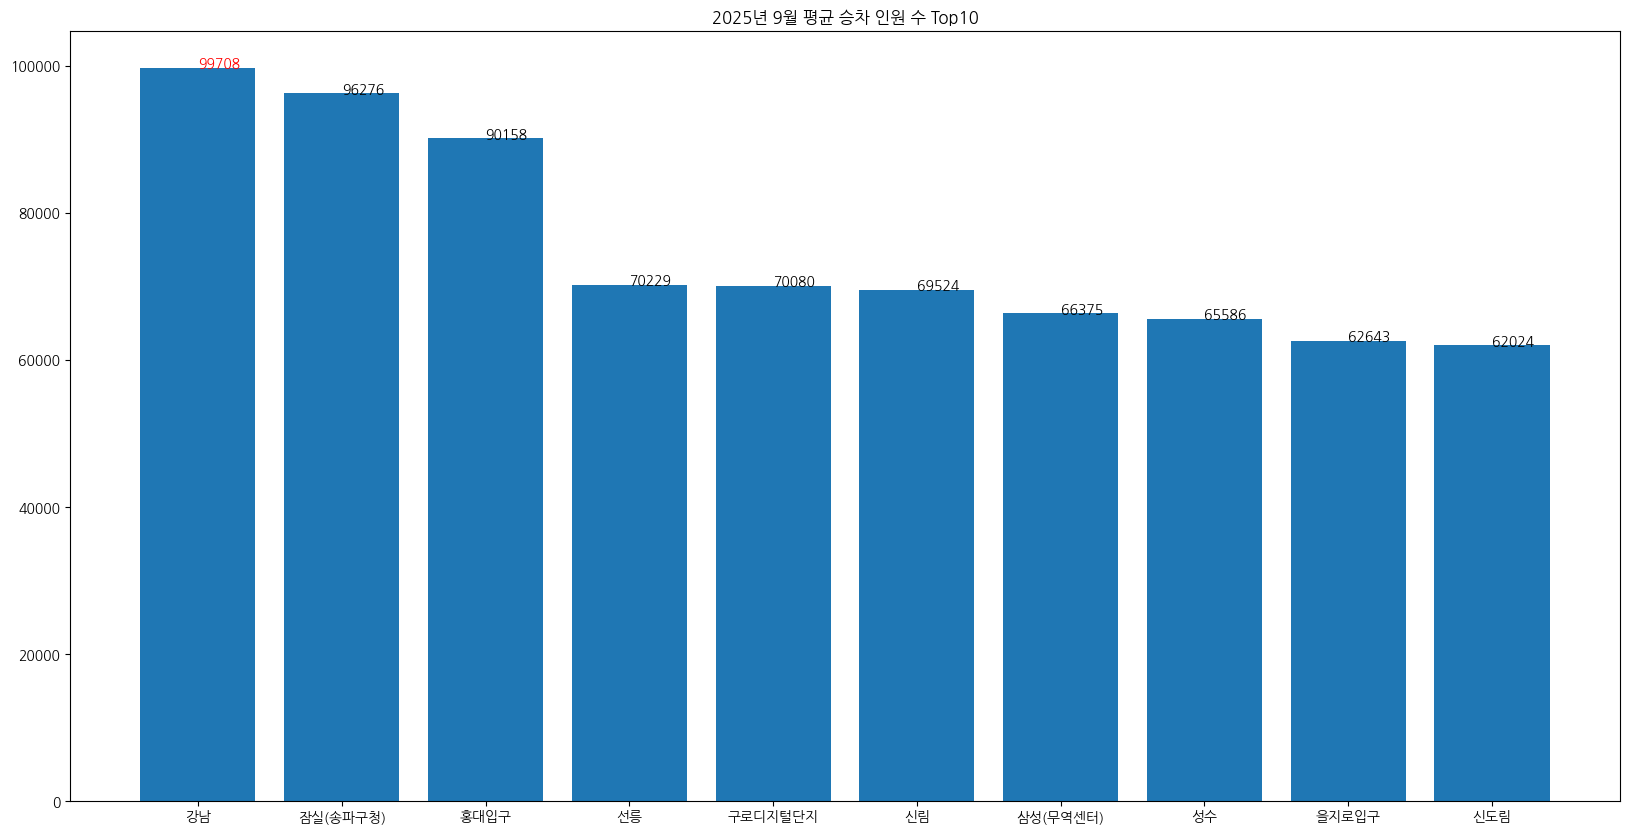

In [43]:
# 평균 승차 인원수 내림차순으로 막대그래프 출력
top10_on = df.sort_values(by='평균 승차 인원 수', ascending=False).head(10)
plt.figure(figsize=(20,10))
plt.bar(top10_on.index, top10_on['평균 승차 인원 수'])
for x, y in enumerate(top10_on['평균 승차 인원 수']):
    if x == 0:
        plt.annotate(y, (x, y), color='red')
    else:
        plt.annotate(y, (x, y))
plt.title('2025년 9월 평균 승차 인원 수 Top10')
plt.show()

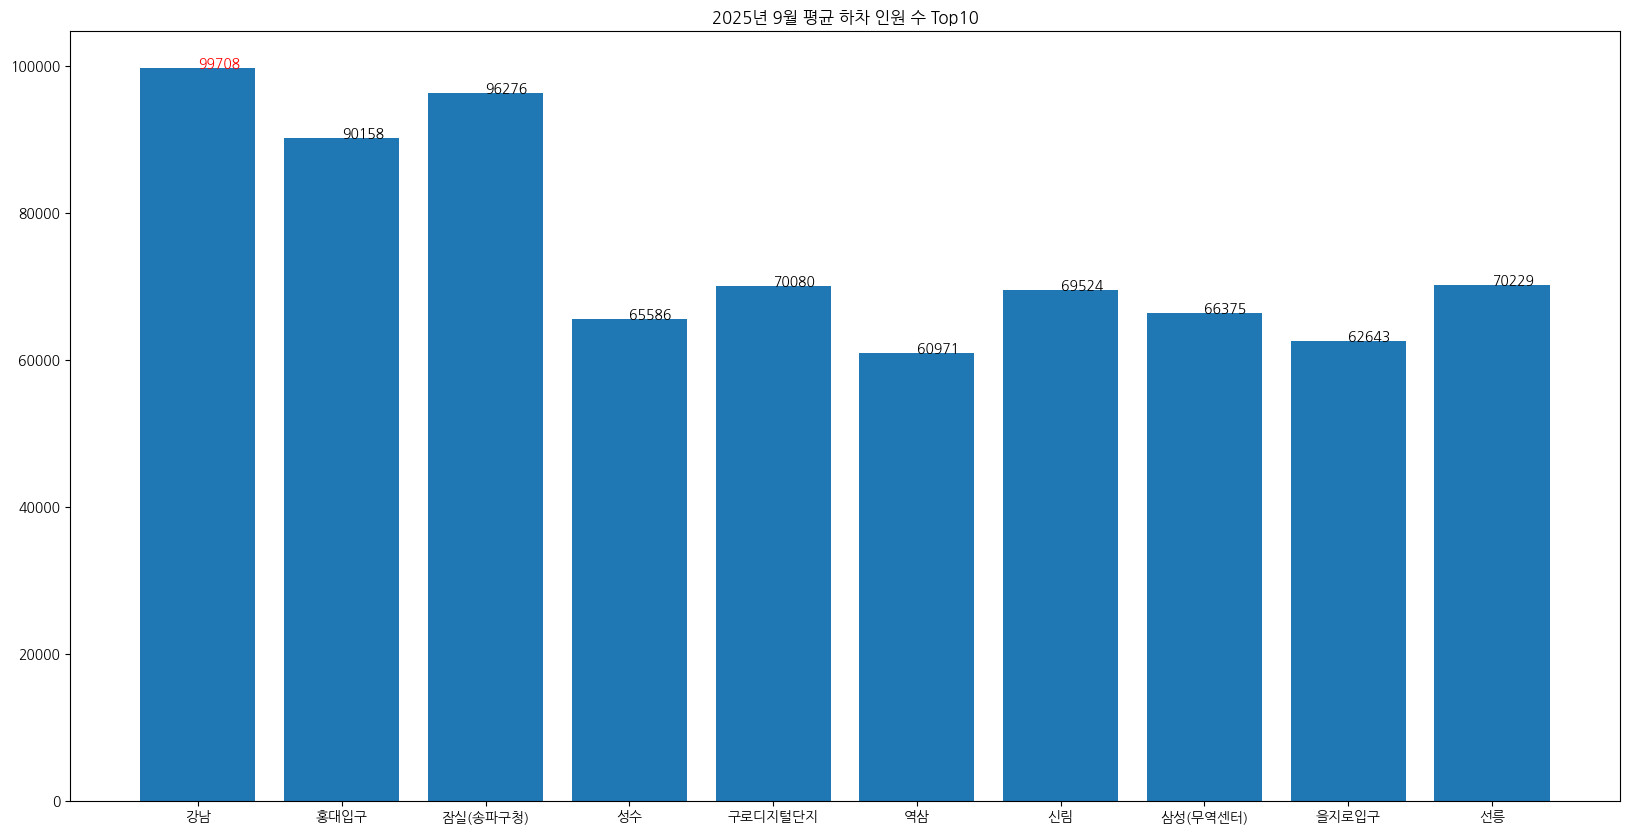

In [46]:
# 평균 하차 인원수 내림차순으로 막대그래프 출력
top10_off = df.sort_values(by='평균 하차 인원 수', ascending=False).head(10)
plt.figure(figsize=(20,10))
plt.bar(top10_off.index, top10_off['평균 승차 인원 수'])
for x, y in enumerate(top10_off['평균 승차 인원 수']):
    if x == 0:
        plt.annotate(y, (x, y), color='red')
    else:
        plt.annotate(y, (x, y))
plt.title('2025년 9월 평균 하차 인원 수 Top10')
plt.show()

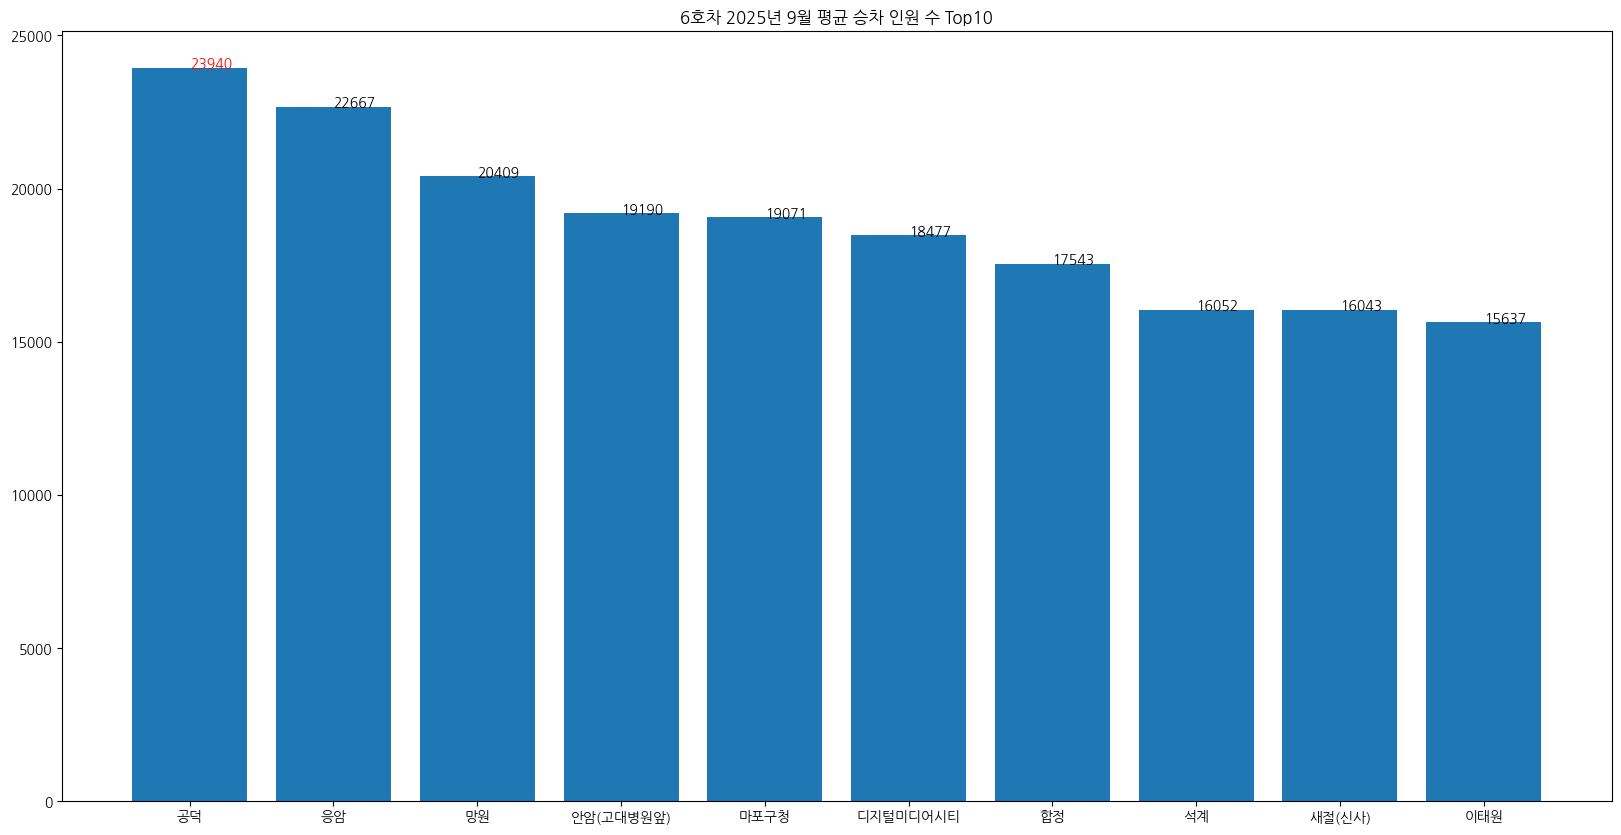

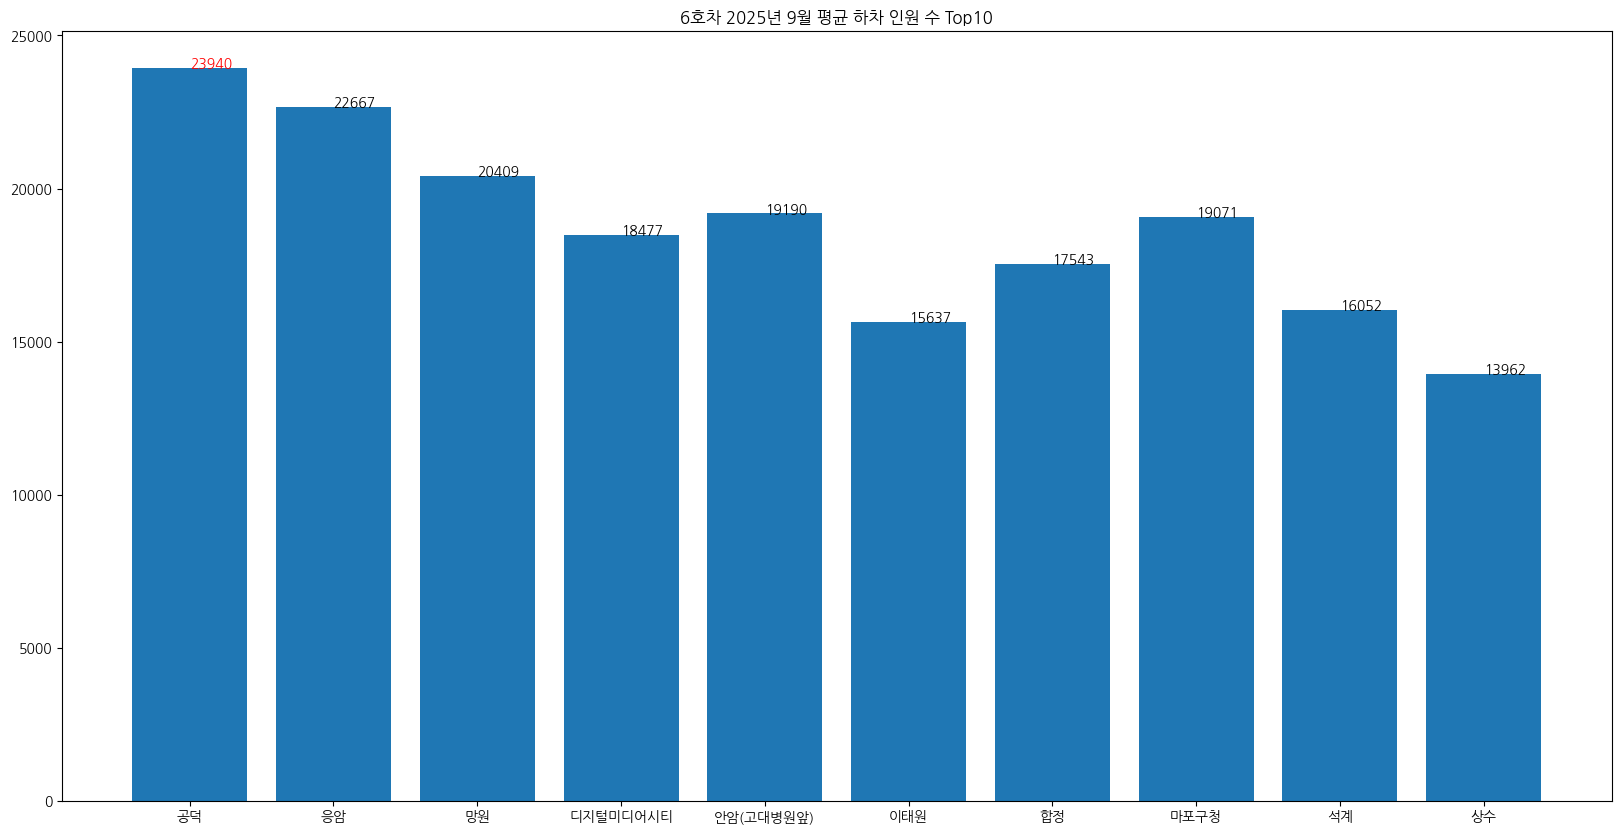

In [52]:
# 6호선의 지하철 역 중에서 승차인원의 수가 가장 많은 역명을 구하세요
# 특정 호선에서 역별 평균 승하차 인원 데이터 추출
line = '6호선'
data_st = data.groupby(['호선명','지하철역']).mean().reset_index()
data_line2 = data_st[data_st['호선명']==line]
data_line2
# 승하차 인원은 홀/짝
# 호선명 ,지하철역,사용월 3개 컬럼을 제외한 갯수의 홀/짝 각각의 수를 구해야한다.
# 승차 인원 컬럼만 추출

data_get_on = pd.DataFrame()
data_get_on['지하철역'] = data_line2['지하철역']

cols =data_line2.columns[3:]
data_get_on = pd.concat([data_get_on,data_line2[cols[::2]]],axis=1)

data_get_on = data_get_on.set_index('지하철역')
data_get_on

# 승차 인원 컬럼만 추출

data_get_off = pd.DataFrame()
data_get_off['지하철역'] = data_line2['지하철역']

cols =data_line2.columns[3:]
data_get_off = pd.concat([data_get_off,data_line2[cols[1::2]]],axis=1)

data_get_off = data_get_off.set_index('지하철역')
data_get_off

# 역 별 평균 승하차 인원을 구한 후, 정수로 변환하여 데이터프레임에 저장
df = pd.DataFrame(index=data_line2['지하철역'])
df['평균 승차 인원 수'] = data_get_on.mean(axis=1).astype(int)
df['평균 하차 인원 수'] = data_get_off.mean(axis=1).astype(int)
df
# 평균 승차 인원수 내림차순으로 막대그래프 출력
top10_on = df.sort_values(by='평균 승차 인원 수', ascending=False).head(10)
plt.figure(figsize=(20,10))
plt.bar(top10_on.index, top10_on['평균 승차 인원 수'])
for x, y in enumerate(top10_on['평균 승차 인원 수']):
    if x == 0:
        plt.annotate(y, (x, y), color='red')
    else:
        plt.annotate(y, (x, y))
plt.title('6호차 2025년 9월 평균 승차 인원 수 Top10')
plt.show()
# 평균 하차 인원수 내림차순으로 막대그래프 출력
top10_off = df.sort_values(by='평균 하차 인원 수', ascending=False).head(10)
plt.figure(figsize=(20,10))
plt.bar(top10_off.index, top10_off['평균 승차 인원 수'])
for x, y in enumerate(top10_off['평균 승차 인원 수']):
    if x == 0:
        plt.annotate(y, (x, y), color='red')
    else:
        plt.annotate(y, (x, y))
plt.title('6호차 2025년 9월 평균 하차 인원 수 Top10')
plt.show()